# Olist E-Commerce — Demand Forecasting
**Day 4 Notebook** | Forecast daily order volume per product category using Prophet.

Pipeline: aggregate daily sales → baseline rolling average → Prophet with holidays → evaluate → compare.

## 1. Imports & Load Data

In [55]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
# from plotly.subplots import make_subplots
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

In [56]:
master = pd.read_csv(
    '../processed/master_orders.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ]
)

In [57]:
delivered = master[master['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(delivered):,}')

Delivered orders: 97,007


## 2. Aggregate Daily Sales by Category
Resample to daily order counts per category. Top 5 categories by volume only — 
smaller categories don't have enough data for reliable forecasting.

In [58]:
# top 5 categories by order volume
top5_cats = (
    delivered['category_english']
    .value_counts()
    .head(5)
    .index.tolist()
)
print('Top 5 categories:', top5_cats)


# daily order count per category
daily = (
    delivered[delivered['category_english'].isin(top5_cats)]
    .groupby(['category_english',
              delivered['order_purchase_timestamp'].dt.date])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'date', 'order_id': 'n_orders'})
)
daily['date'] = pd.to_datetime(daily['date'])

# also build total daily (all categories) for overview
daily_total = (
    delivered
    .groupby(delivered['order_purchase_timestamp'].dt.date)['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'date', 'order_id': 'n_orders'})
)
daily_total['date'] = pd.to_datetime(daily_total['date'])

print(f'\nDaily records per category:')
print(daily.groupby('category_english')['date'].count().to_string())

Top 5 categories: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor']

Daily records per category:
category_english
bed_bath_table           597
computers_accessories    592
furniture_decor          604
health_beauty            602
sports_leisure           603


## 3. Visualise Raw Daily Series

In [59]:
fig = px.line(
    daily, x='date', y='n_orders',
    color='category_english',
    title='Daily Order Volume — Top 5 Categories',
    labels={'date': 'Date', 'n_orders': 'Orders / Day', 'category_english': 'Category'}
)
fig.update_layout(
    height=420,
    plot_bgcolor='#0c0e0a', paper_bgcolor='#111410',
    font=dict(color='#e4e8e0')
)
fig.show()

# Black Friday spike check
bf_date = '2017-11-24'
bf_orders = daily_total[daily_total['date'] == bf_date]['n_orders'].values
avg_orders = daily_total['n_orders'].mean()
if len(bf_orders):
    print(f'Black Friday {bf_date}: {bf_orders[0]} orders ({bf_orders[0]/avg_orders:.1f}x average)')

Black Friday 2017-11-24: 1156 orders (7.3x average)


## 4. Train / Test Split
Holdout the last 60 days as the test set. Train on everything before that.
60 days is enough to measure forecasting quality on seasonal patterns.

In [60]:
HOLDOUT_DAYS = 60
cutoff = daily_total['date'].max() - pd.Timedelta(days=HOLDOUT_DAYS)
print(f'Train period: up to {cutoff.date()}')
print(f'Test period:  {cutoff.date()} to {daily_total["date"].max().date()} ({HOLDOUT_DAYS} days)')

Train period: up to 2018-06-30
Test period:  2018-06-30 to 2018-08-29 (60 days)


## 5. Baseline — 7-Day Rolling Average
Always benchmark against a simple baseline before Prophet.
If Prophet doesn't clearly beat a rolling average, something is wrong.

In [61]:
def rolling_avg_forecast(series_df, holdout_days=60, window=7):
    df = series_df.sort_values('date').copy()
    train = df[df['date'] <= cutoff]
    test  = df[df['date'] >  cutoff]

    # use last window days of training as forecast for all test days
    baseline_value = train['n_orders'].tail(window).mean()
    test = test.copy()
    test['predicted'] = baseline_value
    return test

# run on total daily series
baseline_results = rolling_avg_forecast(daily_total)
baseline_mae  = mean_absolute_error(baseline_results['n_orders'], baseline_results['predicted'])
baseline_mape = (np.abs(baseline_results['n_orders'] - baseline_results['predicted'])
                 / baseline_results['n_orders'].replace(0, np.nan)).mean() * 100

print(f'Rolling Average Baseline (7-day):')
print(f'  MAE:  {baseline_mae:.1f} orders/day')
print(f'  MAPE: {baseline_mape:.1f}%')

Rolling Average Baseline (7-day):
  MAE:  67.9 orders/day
  MAPE: 73.2%


## 6. Prophet Forecasting
Prophet is designed for business time series with strong seasonality and holiday effects.
We add Brazilian public holidays as special events — they cause visible spikes and dips.

In [62]:
# Brazilian public holidays 2016-2018
br_holidays = pd.DataFrame({
    'holiday': [
        'Carnaval','Carnaval','Tiradentes','Tiradentes',
        'Dia do Trabalho','Dia do Trabalho',
        'Corpus Christi','Corpus Christi',
        'Independencia','Independencia',
        'Nossa Senhora','Nossa Senhora',
        'Finados','Finados',
        'Proclamacao','Proclamacao',
        'Natal','Natal',
        'Ano Novo','Ano Novo',
        'Black Friday','Black Friday',
    ],
    'ds': pd.to_datetime([
        '2017-02-28','2018-02-13',
        '2017-04-21','2018-04-21',
        '2017-05-01','2018-05-01',
        '2017-06-15','2018-05-31',
        '2017-09-07','2018-09-07',
        '2017-10-12','2018-10-12',
        '2017-11-02','2018-11-02',
        '2017-11-15','2018-11-15',
        '2017-12-25','2018-12-25',
        '2017-01-01','2018-01-01',
        '2017-11-24','2018-11-23',
    ]),
    'lower_window': 0,
    'upper_window': 1,
})

In [63]:
def run_prophet(category_df, category_name, holdout_days=60):
    df = category_df.sort_values('date').copy()
    train = df[df['date'] <= cutoff].rename(columns={'date':'ds','n_orders':'y'})
    test  = df[df['date'] >  cutoff].rename(columns={'date':'ds','n_orders':'y'})

    m = Prophet(
        holidays=br_holidays,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        interval_width=0.80
    )
    m.fit(train)

    future   = m.make_future_dataframe(periods=holdout_days)
    forecast = m.predict(future)

    # merge forecast with actuals on test period
    test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
    test_merged   = test.merge(test_forecast, on='ds', how='inner')
    test_merged['yhat'] = test_merged['yhat'].clip(lower=0)

    mae  = mean_absolute_error(test_merged['y'], test_merged['yhat'])
    mape = (np.abs(test_merged['y'] - test_merged['yhat'])
            / test_merged['y'].replace(0, np.nan)).mean() * 100

    print(f'{category_name:35} MAE: {mae:5.1f}  MAPE: {mape:5.1f}%')
    return m, forecast, test_merged, mae, mape

print('Running Prophet for each category...')
print(f'{"Category":35} {"MAE":>10}  {"MAPE":>8}')
print('-' * 58)

prophet_results = {}
for cat in top5_cats:
    cat_df = daily[daily['category_english'] == cat][['date','n_orders']].copy()
    model, forecast, test_merged, mae, mape = run_prophet(cat_df, cat)
    prophet_results[cat] = {
        'model': model, 'forecast': forecast,
        'test': test_merged, 'mae': mae, 'mape': mape
    }

Running Prophet for each category...
Category                                   MAE      MAPE
----------------------------------------------------------


20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing
20:33:51 - cmdstanpy - INFO - Chain [1] start processing


bed_bath_table                      MAE:   7.2  MAPE:  75.1%


20:33:51 - cmdstanpy - INFO - Chain [1] done processing


health_beauty                       MAE:   7.8  MAPE:  62.4%


...

sports_leisure                      MAE:   4.9  MAPE:  56.8%


20:33:52 - cmdstanpy - INFO - Chain [1] start processing
20:33:52 - cmdstanpy - INFO - Chain [1] done processing
20:33:52 - cmdstanpy - INFO - Chain [1] start processing


computers_accessories               MAE:   6.2  MAPE:  52.5%


20:33:52 - cmdstanpy - INFO - Chain [1] done processing


furniture_decor                     MAE:   5.4  MAPE:  97.8%


## 7. Visualise Forecast vs Actuals

In [64]:
# plot for the top category
top_cat = top5_cats[0]
res     = prophet_results[top_cat]
fc      = res['forecast']
test_df = res['test']

# full training history
train_df = daily[daily['category_english'] == top_cat]
train_df = train_df[train_df['date'] <= cutoff]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=train_df['date'], y=train_df['n_orders'],
    mode='lines', name='Train actuals',
    line=dict(color='#6a7068', width=1)
))
fig.add_trace(go.Scatter(
    x=test_df['ds'], y=test_df['y'],
    mode='lines+markers', name='Test actuals',
    line=dict(color='#e4e8e0', width=2)
))
fig.add_trace(go.Scatter(
    x=test_df['ds'], y=test_df['yhat'],
    mode='lines', name='Prophet forecast',
    line=dict(color='#4ade80', width=2)
))
fig.add_trace(go.Scatter(
    x=pd.concat([test_df['ds'], test_df['ds'][::-1]]),
    y=pd.concat([test_df['yhat_upper'], test_df['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(74,222,128,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='80% CI'
))

fig.update_layout(
    title=f'Prophet Forecast vs Actuals — {top_cat}',
    xaxis_title='Date', yaxis_title='Daily Orders',
    height=450,
    plot_bgcolor='#0c0e0a', paper_bgcolor='#111410',
    font=dict(color='#e4e8e0')
)
fig.show()

## 8. Compare Prophet vs Baseline

In [65]:
print('=== PROPHET vs ROLLING AVERAGE BASELINE ===')
print(f'{"Category":35} {"Baseline MAPE":>14} {"Prophet MAPE":>13} {"Improvement":>12}')
print('-' * 78)

for cat in top5_cats:
    cat_df = daily[daily['category_english'] == cat][['date','n_orders']].copy()
    bl = rolling_avg_forecast(cat_df.rename(columns={'date':'date','n_orders':'n_orders'}))
    bl_mape = (np.abs(bl['n_orders'] - bl['predicted'])
               / bl['n_orders'].replace(0, np.nan)).mean() * 100
    pr_mape = prophet_results[cat]['mape']
    improvement = bl_mape - pr_mape
    print(f'{cat:35} {bl_mape:>13.1f}% {pr_mape:>12.1f}% {improvement:>+11.1f}%')

=== PROPHET vs ROLLING AVERAGE BASELINE ===
Category                             Baseline MAPE  Prophet MAPE  Improvement
------------------------------------------------------------------------------
bed_bath_table                               68.8%         75.1%        -6.3%
health_beauty                                65.2%         62.4%        +2.9%
sports_leisure                               67.6%         56.8%       +10.8%
computers_accessories                        65.5%         52.5%       +13.0%
furniture_decor                              78.1%         97.8%       -19.8%


## 9. Component Plots — What Drives the Forecast?

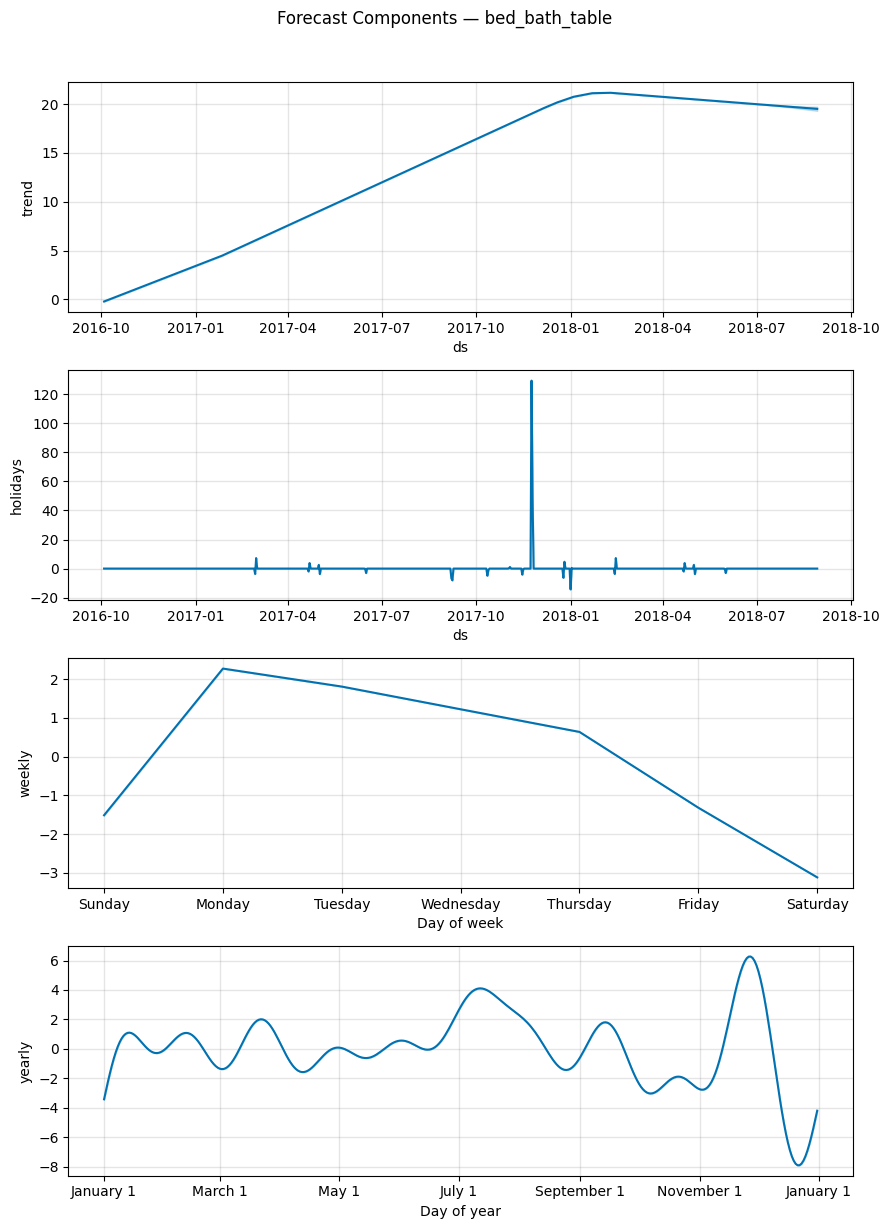

In [66]:
# Prophet's built-in component decomposition
top_model = prophet_results[top5_cats[0]]['model']
top_fc    = prophet_results[top5_cats[0]]['forecast']
fig_comp  = top_model.plot_components(top_fc)
fig_comp.suptitle(f'Forecast Components — {top5_cats[0]}', y=1.02)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

**Finding:** *(fill in after running)*
e.g. Prophet achieves MAPE of X% vs Y% for rolling average — a Z% improvement.
Black Friday 2017 spike captured well. Weekly seasonality: Tuesday peak clearly visible in components.

## 10. Save Results

In [67]:
os.makedirs('../processed', exist_ok=True)

# save all forecasts as one CSV
forecast_rows = []
for cat in top5_cats:
    fc = prophet_results[cat]['forecast'][['ds','yhat','yhat_lower','yhat_upper']].copy()
    fc['category'] = cat
    forecast_rows.append(fc)

all_forecasts = pd.concat(forecast_rows, ignore_index=True)
all_forecasts.to_csv('../processed/demand_forecasts.csv', index=False)
print(f'Saved: ../processed/demand_forecasts.csv ({len(all_forecasts):,} rows)')

# summary metrics
metrics = pd.DataFrame([
    {'category': cat, 'prophet_mape': prophet_results[cat]['mape'],
     'prophet_mae': prophet_results[cat]['mae']}
    for cat in top5_cats
])
print('\nFinal metrics:')
print(metrics.to_string(index=False))

Saved: ../processed/demand_forecasts.csv (3,001 rows)

Final metrics:
             category  prophet_mape  prophet_mae
       bed_bath_table     75.094741     7.240305
        health_beauty     62.358868     7.803035
       sports_leisure     56.834779     4.872982
computers_accessories     52.502855     6.165940
      furniture_decor     97.840257     5.425391


In [68]:
# ── AUTO SUMMARY — runs from live variables ──────────────────────────
import pandas as pd

print('=' * 60)
print('DEMAND FORECASTING SUMMARY')
print('=' * 60)

# black friday
bf_orders = daily_total[daily_total['date'] == '2017-11-24']['n_orders'].values
avg_orders = daily_total['n_orders'].mean()
if len(bf_orders):
    print(f'\nBlack Friday 2017-11-24: {bf_orders[0]} orders ({bf_orders[0]/avg_orders:.1f}x average)')

# baseline
print(f'\nBaseline (7-day rolling average):')
print(f'  MAE:  {baseline_mae:.1f} orders/day')
print(f'  MAPE: {baseline_mape:.1f}%')

# prophet vs baseline per category
print(f'\nProphet vs Baseline:')
rows = []
for cat in top5_cats:
    cat_df = daily[daily['category_english'] == cat][['date','n_orders']].copy()
    bl = rolling_avg_forecast(cat_df)
    bl_mape = (abs(bl['n_orders'] - bl['predicted']) / bl['n_orders'].replace(0, float('nan'))).mean() * 100
    pr_mape = prophet_results[cat]['mape']
    pr_mae  = prophet_results[cat]['mae']
    rows.append({
        'Category':      cat,
        'Baseline MAPE': f'{bl_mape:.1f}%',
        'Prophet MAPE':  f'{pr_mape:.1f}%',
        'Prophet MAE':   f'{pr_mae:.1f}',
        'Improvement':   f'{bl_mape - pr_mape:+.1f}%',
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

best_cat = min(prophet_results, key=lambda c: prophet_results[c]['mape'])
print(f'\nBest category: {best_cat} (MAPE {prophet_results[best_cat]["mape"]:.1f}%)')
print(f'Worst category: {max(prophet_results, key=lambda c: prophet_results[c]["mape"])}')

print('\nOutput saved: ../processed/demand_forecasts.csv')
print('Next: 05_segmentation.ipynb')


DEMAND FORECASTING SUMMARY

Black Friday 2017-11-24: 1156 orders (7.3x average)

Baseline (7-day rolling average):
  MAE:  67.9 orders/day
  MAPE: 73.2%

Prophet vs Baseline:
             Category Baseline MAPE Prophet MAPE Prophet MAE Improvement
       bed_bath_table         68.8%        75.1%         7.2       -6.3%
        health_beauty         65.2%        62.4%         7.8       +2.9%
       sports_leisure         67.6%        56.8%         4.9      +10.8%
computers_accessories         65.5%        52.5%         6.2      +13.0%
      furniture_decor         78.1%        97.8%         5.4      -19.8%

Best category: computers_accessories (MAPE 52.5%)
Worst category: furniture_decor

Output saved: ../processed/demand_forecasts.csv
Next: 05_segmentation.ipynb
